In [2]:
import numpy as np

In [22]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [98]:
class Value:
    def __init__(self, data, label = '', parents=(), _op=None):
        self.data = data
        self._prev = set(parents)
        self.label = label
        self.grad = 0
        self._op = _op
        self._backward = lambda: None
    def __add__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        result = Value(data = self.data + other.data, parents=(self, other), _op='+')
        def _backward():
            self.grad += result.grad
            other.grad += result.grad
        result._backward = _backward
        return result
    def __mul__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        result = Value(data = self.data * other.data, parents=(self, other), _op='*')
        def _backward():
            self.grad += result.grad * other.data
            other.grad += result.grad * self.data
        result._backward = _backward
        return result
    def __neg__(self):
        return self * -1
    def __sub__(self, other):
        return self + (-other)
    def tanh(self):
        tanh = lambda x: (np.e ** (2*x) - 1)/(np.e ** (2*x) + 1)
        result = Value(data = tanh(self.data), parents=(self,), _op='tanh')
        def _backward():
            self.grad += (1 - result.data ** 2) * result.grad
        result._backward = _backward
        return result
    def exp(self): 
        result = Value(np.e**self.data, parents=(self,), _op='exp')
        def _backward():
            print(result.data, result.grad)
            self.grad += result.data * result.grad
        result._backward = _backward
        return result
    def __pow__(self, other):
        # Here other is int or float, not Value
        result = Value(self.data ** other, parents=(self,), _op='pow')
        def _backward():
            self.grad += other * result.data / self.data * result.grad
        result._backward = _backward
        return result
    def __truediv__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        return self * other ** -1
    def __radd__(self, other):
        return self + other
    def __rmul__(self, other):
        return self * other
    def __repr__(self):
        return f"Value(data={self.data})"
    def zero_grad(self):
        self.grad = 0
        for p in self._prev:
            p.zero_grad()
    def backward(self, is_result=True):
        if is_result:
            self.grad = 1.0
        self._backward()
        for parent in self._prev:
            parent.backward(is_result=False)

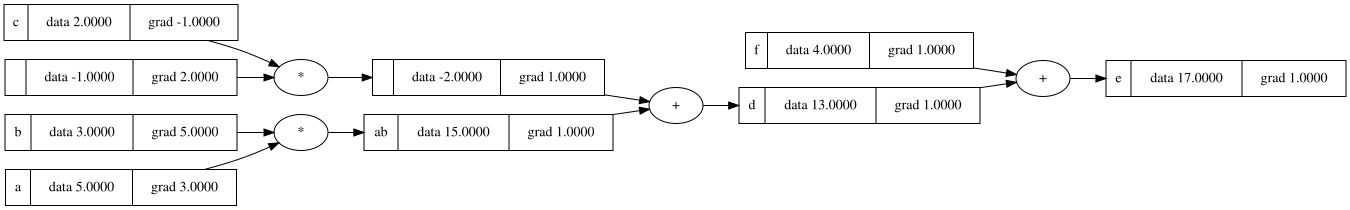

In [56]:
a = Value(5)
a.label = 'a'
b = Value(3)
b.label = 'b'
c = Value(2)
c.label = 'c'
ab = a * b
ab.label = 'ab'
d = ab + (-c)
d.label = 'd'
f = Value(4)
f.label = 'f'
e = d + f
e.label = 'e'

e.zero_grad()
e.backward()
draw_dot(e)

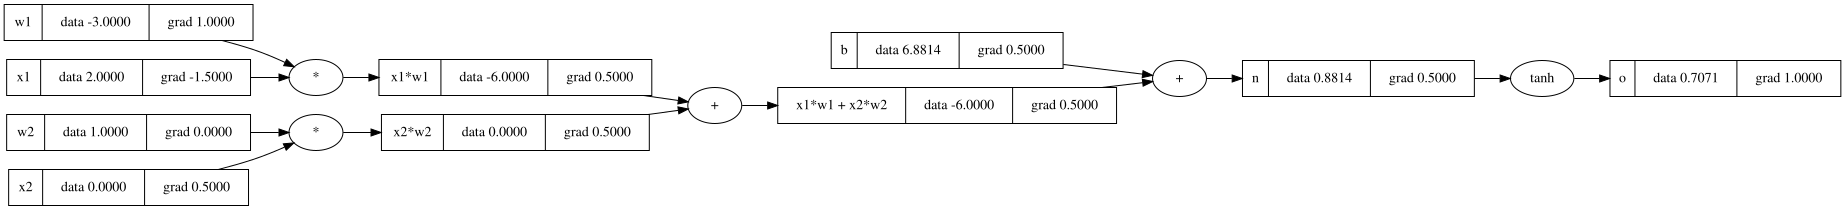

In [78]:


# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.zero_grad()
o.backward()

draw_dot(o)

5.828427124746191 -0.10355339059327374
5.828427124746191 0.04289321881345247


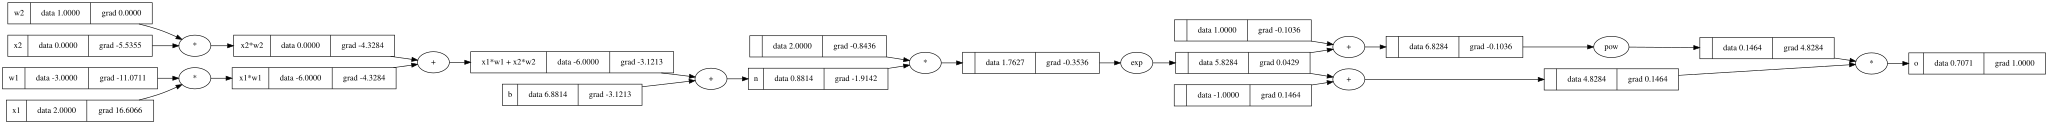

In [99]:


# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# # ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.zero_grad()
o.backward()
draw_dot(o)

